In [21]:

# 1. 데이터 경로 설정
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

b2_lazy = pl.scan_parquet(B2_PATH)
b4_lazy = pl.scan_parquet(B4_PATH)

In [1]:
import polars as pl
import os

"""
[데이터 기초 점검: B2_POS_SALE.parquet]

1. 분석 목적:
   - POS 판매 데이터의 스키마(컬럼명, 데이터 타입)를 파악함.
   - 실제 데이터 샘플을 확인하여 전처리 상태를 점검함.
   - 데이터 규모(행 수) 및 결측치 여부를 진단함.

2. 통계적 방법론:
   - Polars Lazy API를 사용하여 메모리 전체를 로드하지 않고 메타데이터 추출.
   - 전체 행 수 및 컬럼별 Null 값 집계 수행.
"""

# 1. 데이터 경로 설정
DATA_PATH = 'data/processed/B2_POS_SALE.parquet'
ALT_PATH = '/Users/hajiyoon/workspace/data/processed/B2_POS_SALE.parquet'

if not os.path.exists(DATA_PATH):
    if os.path.exists(ALT_PATH):
        DATA_PATH = ALT_PATH
    else:
        print(f"⚠️ 데이터를 찾을 수 없습니다. 경로를 확인해주세요.")
        exit()

print(f"🔍 데이터 점검을 시작합니다: {DATA_PATH}\n")

# 2. 데이터 스키마 및 샘플 로드 (Lazy)
b2_lazy = pl.scan_parquet(DATA_PATH)

# 3. 데이터 구조 및 스키마 확인
print("--- [1] 데이터 스키마 (Schema) ---")
for col, dtype in b2_lazy.schema.items():
    print(f"- {col}: {dtype}")
print("\n")

# 4. 데이터 샘플 확인 (상위 5개 행)
print("--- [2] 데이터 샘플 (Top 5 Rows) ---")
sample_df = b2_lazy.head(5).collect()
print(sample_df)
print("\n")

# 5. 데이터 규모 및 결측치 점검
print("--- [3] 데이터 규모 및 결측치 (Null Count) ---")
total_rows = b2_lazy.select(pl.len()).collect().item()
print(f"전체 행(Row) 수: {total_rows:,} 건")

null_counts = b2_lazy.select(pl.all().null_count()).collect()
print("\n컬럼별 결측치 수:")
print(null_counts)


🔍 데이터 점검을 시작합니다: /Users/hajiyoon/workspace/data/processed/B2_POS_SALE.parquet

--- [1] 데이터 스키마 (Schema) ---
- 판매일자: String
- 판매시간: String
- 점포코드: String
- POS번호: String
- 거래번호: String
- 상품코드: String
- 판매수량: Int64
- 판매금액: Int64


--- [2] 데이터 샘플 (Top 5 Rows) ---
shape: (5, 8)
┌──────────┬──────────┬──────────┬─────────┬──────────┬──────────┬──────────┬──────────┐
│ 판매일자 ┆ 판매시간 ┆ 점포코드 ┆ POS번호 ┆ 거래번호 ┆ 상품코드 ┆ 판매수량 ┆ 판매금액 │
│ ---      ┆ ---      ┆ ---      ┆ ---     ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ str      ┆ str      ┆ str      ┆ str     ┆ str      ┆ str      ┆ i64      ┆ i64      │
╞══════════╪══════════╪══════════╪═════════╪══════════╪══════════╪══════════╪══════════╡
│ 20250523 ┆ 084531   ┆ 64139    ┆ 02      ┆ 26651    ┆ 314952   ┆ 1        ┆ 500      │
│ 20250523 ┆ 105724   ┆ 52657    ┆ 01      ┆ 48727    ┆ 314954   ┆ 10       ┆ 45000    │
│ 20250523 ┆ 105724   ┆ 52657    ┆ 01      ┆ 48727    ┆ 314952   ┆ 10       ┆ 5000     │
│ 20250523 ┆ 084531   ┆ 64139    ┆ 02      

/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_82096/4126771892.py:35: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  for col, dtype in b2_lazy.schema.items():



컬럼별 결측치 수:
shape: (1, 8)
┌──────────┬──────────┬──────────┬─────────┬──────────┬──────────┬──────────┬──────────┐
│ 판매일자 ┆ 판매시간 ┆ 점포코드 ┆ POS번호 ┆ 거래번호 ┆ 상품코드 ┆ 판매수량 ┆ 판매금액 │
│ ---      ┆ ---      ┆ ---      ┆ ---     ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ u32      ┆ u32      ┆ u32      ┆ u32     ┆ u32      ┆ u32      ┆ u32      ┆ u32      │
╞══════════╪══════════╪══════════╪═════════╪══════════╪══════════╪══════════╪══════════╡
│ 0        ┆ 0        ┆ 0        ┆ 0       ┆ 0        ┆ 0        ┆ 0        ┆ 0        │
└──────────┴──────────┴──────────┴─────────┴──────────┴──────────┴──────────┴──────────┘


In [ ]:
import polars as pl
import os

"""
[핵심 상품군(Top 5%) 카테고리 및 아이템 비중 분석]

1. 분석 목적:
   - 매출액 및 판매수량 기준 상위 5% 상품(95th Quantile)을 식별함.
   - 상위 상품군 내 중분류/소분류 카테고리 구성 비율을 파악함.
   - 각 카테고리 내 개별 아이템의 기여도(Concentration)를 분석함.

2. 통계적 방법론:
   - POS 데이터(B2)와 상품 마스터(B4)를 ITEM_CD 기준으로 Inner Join.
   - 상품별 누적 매출/수량 집계 및 상위 5% 임계값 산출.
   - 카테고리별 비중 산출 및 아이템별 점유율(Share) 계산.
"""

# 1. 데이터 경로 설정
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
    print(f"⚠️ 데이터를 찾을 수 없습니다.\n- B2: {B2_PATH}\n- B4: {B4_PATH}")
    exit()

print(f"📊 분석 시작: B2({B2_PATH}), B4({B4_PATH})\n")

# 2. 데이터 로드 및 결합 (Lazy)
b2_lazy = pl.scan_parquet(B2_PATH)
b4_lazy = pl.scan_parquet(B4_PATH)

# 상품별 집계
prod_agg = (
    b2_lazy
    .group_by("상품코드")
    .agg([
        pl.col("판매금액").sum().alias("총매출액"),
        pl.col("판매수량").sum().alias("총판매량")
    ])
)

# B4와 결합 (카테고리 정보 확보)
df_joined = (
    prod_agg
    .join(b4_lazy, left_on="상품코드", right_on="ITEM_CD", how="inner")
)

def analyze_top_5(df, target_col):
    print(f"--- [{target_col}] 기준 상위 5% 분석 ---")
    
    # 1. 상위 5% 임계값 산출
    threshold = df.select(pl.col(target_col).quantile(0.95)).collect().item()
    top_5_df = df.filter(pl.col(target_col) >= threshold).collect()
    
    total_top_val = top_5_df[target_col].sum()
    print(f"상위 5% 상품 수: {len(top_5_df):,}개")
    print(f"기준 임계값: {threshold:,.0f}")
    
    # 2. 중분류 비율
    mid_ratio = (
        top_5_df.group_by("ITEM_MDDV_NM")
        .agg(pl.col(target_col).sum().alias("cat_total"))
        .with_columns((pl.col("cat_total") / total_top_val * 100).alias("ratio"))
        .sort("ratio", descending=True)
    )
    print("\n[중분류별 비중 Top 5]")
    print(mid_ratio.head(5))
    
    # 3. 소분류 비율
    sub_ratio = (
        top_5_df.group_by("ITEM_SMDV_NM")
        .agg(pl.col(target_col).sum().alias("sub_total"))
        .with_columns((pl.col("sub_total") / total_top_val * 100).alias("ratio"))
        .sort("ratio", descending=True)
    )
    print("\n[소분류별 비중 Top 5]")
    print(sub_ratio.head(5))
    
    # 4. 카테고리 내 아이템 비중 (가장 비중 높은 중분류 대상)
    if len(mid_ratio) > 0:
        top_mid = mid_ratio["ITEM_MDDV_NM"][0]
        item_in_cat = (
            top_5_df.filter(pl.col("ITEM_MDDV_NM") == top_mid)
            .with_columns((pl.col(target_col) / pl.col(target_col).sum().over("ITEM_MDDV_NM") * 100).alias("item_share"))
            .select(["ITEM_NM", target_col, "item_share"])
            .sort("item_share", descending=True)
        )
        print(f"\n[최상위 중분류({top_mid}) 내 아이템별 비중 Top 5]")
        print(item_in_cat.head(5))
    print("\n" + "="*50 + "\n")

# 3. 분석 실행
full_data_collected = df_joined.collect()
analyze_top_5(full_data_collected.lazy(), "총매출액")
analyze_top_5(full_data_collected.lazy(), "총판매량")


📊 분석 시작: B2(/Users/hajiyoon/workspace/data/processed/B2_POS_SALE.parquet), B4(/Users/hajiyoon/workspace/data/processed/B4_food_item_data.parquet)

--- [총매출액] 기준 상위 5% 분석 ---
상위 5% 상품 수: 383개
기준 임계값: 46,896,145

[중분류별 비중 Top 5]
shape: (5, 3)
┌──────────────┬────────────┬──────────┐
│ ITEM_MDDV_NM ┆ cat_total  ┆ ratio    │
│ ---          ┆ ---        ┆ ---      │
│ str          ┆ i64        ┆ f64      │
╞══════════════╪════════════╪══════════╡
│ 기능성드링크 ┆ 3475902769 ┆ 8.754479 │
│ 국산맥주     ┆ 2987763410 ┆ 7.525042 │
│ 수입맥주     ┆ 2679016582 ┆ 6.747426 │
│ 생수         ┆ 2533021068 ┆ 6.379718 │
│ 소주         ┆ 2235563990 ┆ 5.630537 │
└──────────────┴────────────┴──────────┘

[소분류별 비중 Top 5]
shape: (5, 3)
┌────────────────┬────────────┬───────────┐
│ ITEM_SMDV_NM   ┆ sub_total  ┆ ratio     │
│ ---            ┆ ---        ┆ ---       │
│ str            ┆ i64        ┆ f64       │
╞════════════════╪════════════╪═══════════╡
│ 캔맥주(중)     ┆ 4247355090 ┆ 10.697475 │
│ 스포츠음료(중) ┆ 1626256002 ┆ 4.095921 

📊 데이터를 분석 및 집계 중입니다 (이 작업은 수 초가 소요될 수 있습니다)...
📈 그래프를 생성하고 있습니다...


/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_82122/838401209.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mid_data, x='ratio', y='ITEM_MDDV_NM', ax=axes_row[0], palette='Blues_r')
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_82122/838401209.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_data, x='ratio', y='ITEM_SMDV_NM', ax=axes_row[1], palette='Reds_r')
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_82122/838401209.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=m

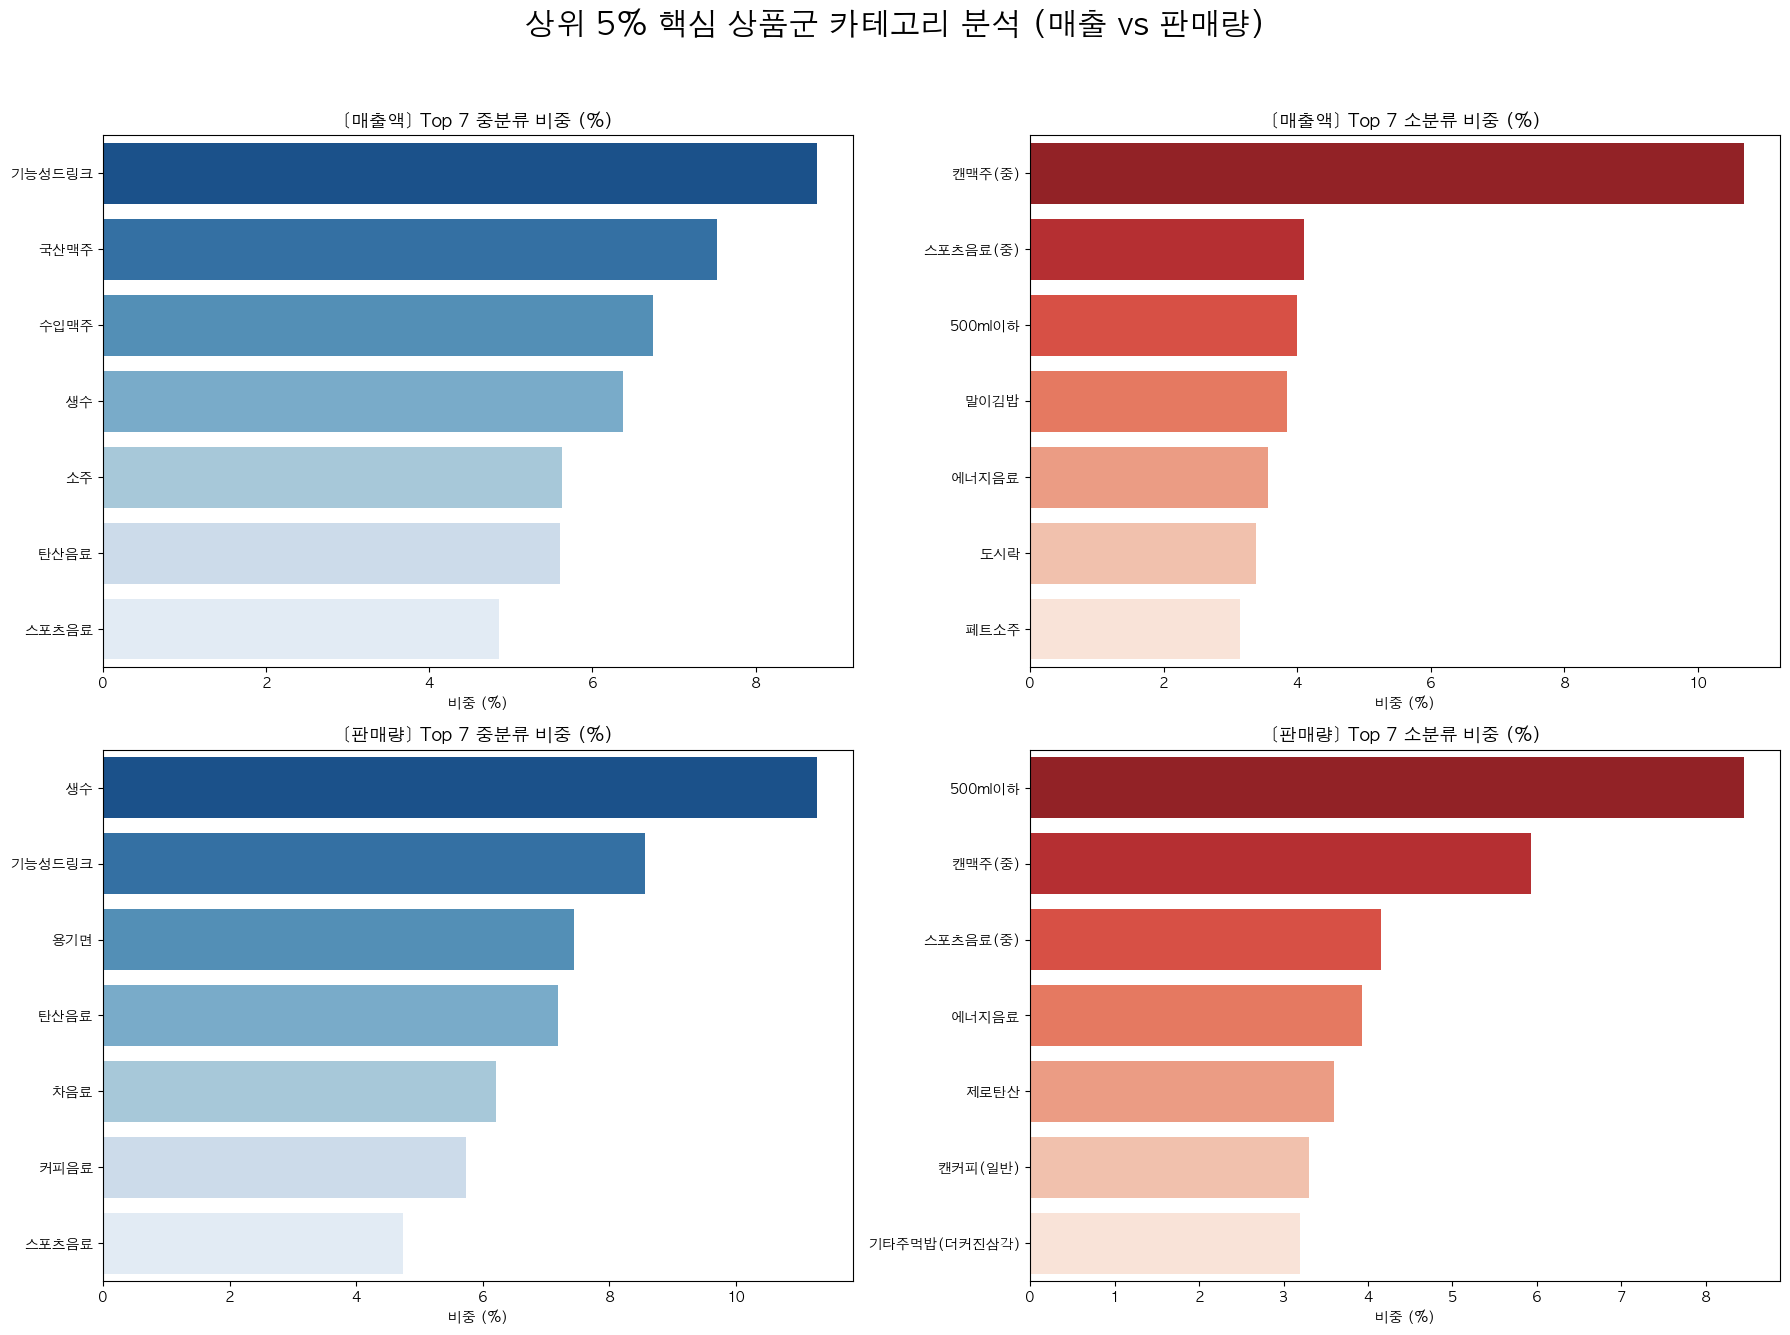

In [ ]:

import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

"""
[상위 5% 핵심 상품군 시각화 분석]

1. 분석 목적:
   - 매출액 상위 5%와 판매수량 상위 5% 상품군의 카테고리 구성을 시각적으로 대조함.
   - 수익성(Revenue)과 회전율(Quantity)의 차이를 파악하여 전략적 인사이트 도출.

2. 시각화 전략:
   - 막대 그래프(Bar Chart): 지표별 Top 7 중분류 및 소분류 비중 시각화.
   - Mac 전용 폰트(AppleGothic) 적용으로 한글 깨짐 방지.
   - 결과를 이미지 파일로 저장하여 보고서 활용도 제고.
"""

# 1. 데이터 경로 설정
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

def run_visualization():
    if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
        print(f"⚠️ 데이터를 찾을 수 없습니다.\n- B2: {B2_PATH}\n- B4: {B4_PATH}")
        return

    # 한글 폰트 설정 (Mac)
    plt.rc('font', family='AppleGothic')
    plt.rcParams['axes.unicode_minus'] = False

    # 2. 데이터 로드 및 집계 (Lazy)
    print("📊 데이터를 분석 및 집계 중입니다 (이 작업은 수 초가 소요될 수 있습니다)...")
    b2_lazy = pl.scan_parquet(B2_PATH)
    b4_lazy = pl.scan_parquet(B4_PATH)

    # 상품별 실적 집계
    prod_agg = (
        b2_lazy.group_by("상품코드")
        .agg([
            pl.col("판매금액").sum().alias("총매출액"),
            pl.col("판매수량").sum().alias("총판매량")
        ])
    )

    # 마스터 정보와 결합 후 메모리 로드
    df_joined = prod_agg.join(b4_lazy, left_on="상품코드", right_on="ITEM_CD", how="inner").collect()

    # 3. 시각화 함수 정의
    def plot_top5_metrics(df, target_col, title_prefix, axes_row):
        # 상위 5% 필터링 (95th Quantile)
        threshold = df[target_col].quantile(0.95)
        top_5_df = df.filter(pl.col(target_col) >= threshold)
        total_val = top_5_df[target_col].sum()

        # 중분류 데이터 준비
        mid_data = (
            top_5_df.group_by("ITEM_MDDV_NM")
            .agg(pl.col(target_col).sum().alias("value"))
            .with_columns((pl.col("value") / total_val * 100).alias("ratio"))
            .sort("ratio", descending=True).head(7).to_pandas()
        )

        # 소분류 데이터 준비
        sub_data = (
            top_5_df.group_by("ITEM_SMDV_NM")
            .agg(pl.col(target_col).sum().alias("value"))
            .with_columns((pl.col("value") / total_val * 100).alias("ratio"))
            .sort("ratio", descending=True).head(7).to_pandas()
        )

        # 그래프 그리기
        sns.barplot(data=mid_data, x='ratio', y='ITEM_MDDV_NM', ax=axes_row[0], palette='Blues_r')
        axes_row[0].set_title(f"[{title_prefix}] Top 7 중분류 비중 (%)", fontsize=13, fontweight='bold')
        axes_row[0].set_xlabel("비중 (%)")
        axes_row[0].set_ylabel("")

        sns.barplot(data=sub_data, x='ratio', y='ITEM_SMDV_NM', ax=axes_row[1], palette='Reds_r')
        axes_row[1].set_title(f"[{title_prefix}] Top 7 소분류 비중 (%)", fontsize=13, fontweight='bold')
        axes_row[1].set_xlabel("비중 (%)")
        axes_row[1].set_ylabel("")

    # 4. 전체 레이아웃 설정 및 실행
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    
    print("📈 그래프를 생성하고 있습니다...")
    plot_top5_metrics(df_joined, "총매출액", "매출액", axes[0])
    plot_top5_metrics(df_joined, "총판매량", "판매량", axes[1])

    plt.suptitle("상위 5% 핵심 상품군 카테고리 분석 (매출 vs 판매량)", fontsize=22, y=0.98, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # 이미지 저장
    # output_path = "eda/top5_percent_analysis.png"
    # plt.savefig(output_path, dpi=300)
    # print(f"✅ 시각화 완료! 결과 이미지 파일: {output_path}")
    # plt.show()

if __name__ == "__main__":
    run_visualization()


1. 매출(Revenue) 기준 상위 5% 분석 (임계값: 약 4,690만 원)
  * 중분류 TOP 5: 기능성드링크(8.75%), 국산맥주(7.53%), 수입맥주(6.75%), 생수(6.38%), 소주(5.63%) 순입니다. 주류와 고단가 건강 음료가 매출을 견인하고 있습니다.
  * 소분류 TOP 5: 캔맥주(중)가 10.7%로 압도적인 1위이며, 스포츠음료와 김밥류가 뒤를 잇습니다.
  * 아이템 비중: '기능성드링크' 내에서는 헛개컨디션(10.86%)과 박카스F(9.97%)가 시장을 양분하며 높은 점유율을 보입니다.

  2. 판매량(Quantity) 기준 상위 5% 분석 (임계값: 약 2.4만 건)
   * 중분류 TOP 5: 생수(11.28%), 기능성드링크(8.57%), 용기면(7.44%), 탄산음료(7.18%), 차음료(6.21%) 순입니다. 일상적으로
     자주 소비되는 생필품 성격의 음료와 편의식이 주를 이룹니다.
   * 소분류 TOP 5: 500ml 이하 음료와 캔맥주, 스포츠음료 순으로 판매 빈도가 높습니다.
   * 아이템 비중: '생수' 내에서는 아이시스500ml(24.9%)와 제주삼다수500ml(20.3%) 두 제품이 전체 생수 판매량의 약 45%를
     차지하는 강력한 집중도를 보입니다.

  3. 비즈니스 인사이트
   * 수익 vs 객수: 매출은 '주류와 숙취해소제'에서, 판매량은 '생수와 음료'에서 집중적으로 발생합니다. 이는 편의점 방문의
     주된 목적이 음료 구매라면, 실제 이익은 동시 구매되는 주류나 고단가 음료에서 창출됨을 시사합니다.
   * 집중도: 생수 카테고리는 특정 상위 브랜드에 대한 충성도가 매우 높으나, 기능성드링크는 상위 5개 상품이 비교적 고르게
     기여하고 있습니다.

그놈의 글렌피딕

In [ ]:
import polars as pl

print("📊 [b2_lazy] 컬럼명:", b2_lazy.columns)
print("📊 [b4_lazy] 컬럼명:", b4_lazy.columns)

📊 [b2_lazy] 컬럼명: ['판매일자', '판매시간', '점포코드', 'POS번호', '거래번호', '상품코드', '판매수량', '판매금액']
📊 [b4_lazy] 컬럼명: ['상품코드', '상품명', '대분류명', '중분류명', '소분류명']


/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_82122/3002734553.py:3: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  print("📊 [b2_lazy] 컬럼명:", b2_lazy.columns)
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_82122/3002734553.py:4: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  print("📊 [b4_lazy] 컬럼명:", b4_lazy.columns)


In [ ]:
# 갑자기 궁금해서 해본 글렌피딕 몇개 팔렸는지 본 것

import polars as pl

# 1. b2_lazy와 b4_lazy 조인하여 글렌피딕 데이터 추출
# 양쪽 모두 '상품코드'를 가지고 있으므로 on="상품코드" 사용
glenfiddich_stats = (
    b2_lazy
    .join(
        b4_lazy.select(["상품코드", "상품명"]), # 필요한 컬럼만 딱 골라서 조인 (최적화)
        on="상품코드", 
        how="left"
    )
    .filter(pl.col("상품명").str.contains("글렌피딕"))
    .group_by("상품명")
    .agg([
        pl.col("판매수량").sum().alias("총판매량"),
        pl.col("판매금액").sum().alias("총매출액")
    ])
    .sort("총매출액", descending=True)
).collect()

print("🥃 [최종 확인] 세븐일레븐 글렌피딕 판매 현황")
print(glenfiddich_stats)

🥃 [최종 확인] 세븐일레븐 글렌피딕 판매 현황
shape: (5, 3)
┌──────────────────────────┬──────────┬──────────┐
│ 상품명                   ┆ 총판매량 ┆ 총매출액 │
│ ---                      ┆ ---      ┆ ---      │
│ str                      ┆ i64      ┆ i64      │
╞══════════════════════════╪══════════╪══════════╡
│ 윌리엄)글렌피딕15년700ml ┆ 39       ┆ 4723700  │
│ 윌리엄)글렌피딕30년      ┆ 3        ┆ 4158000  │
│ APP)글렌피딕15년700ml    ┆ 1        ┆ 98900    │
│ 윌리엄)글렌피딕 40년     ┆ 0        ┆ 0        │
│ 윌리엄)글렌피딕18년700ml ┆ 0        ┆ 0        │
└──────────────────────────┴──────────┴──────────┘


[판매량 상위 5% 상품군의 전체 중분류 비중 분석]


📊 데이터를 집계하고 상위 5% 임계치를 산출 중입니다...
✅ 상위 5% 상품 기준 판매량: 24,118건 이상
✅ 분석 대상 상품 수: 383개
✅ 추출된 총 중분류 개수: 44개
📈 모든 중분류 비중 차트를 생성 중입니다...


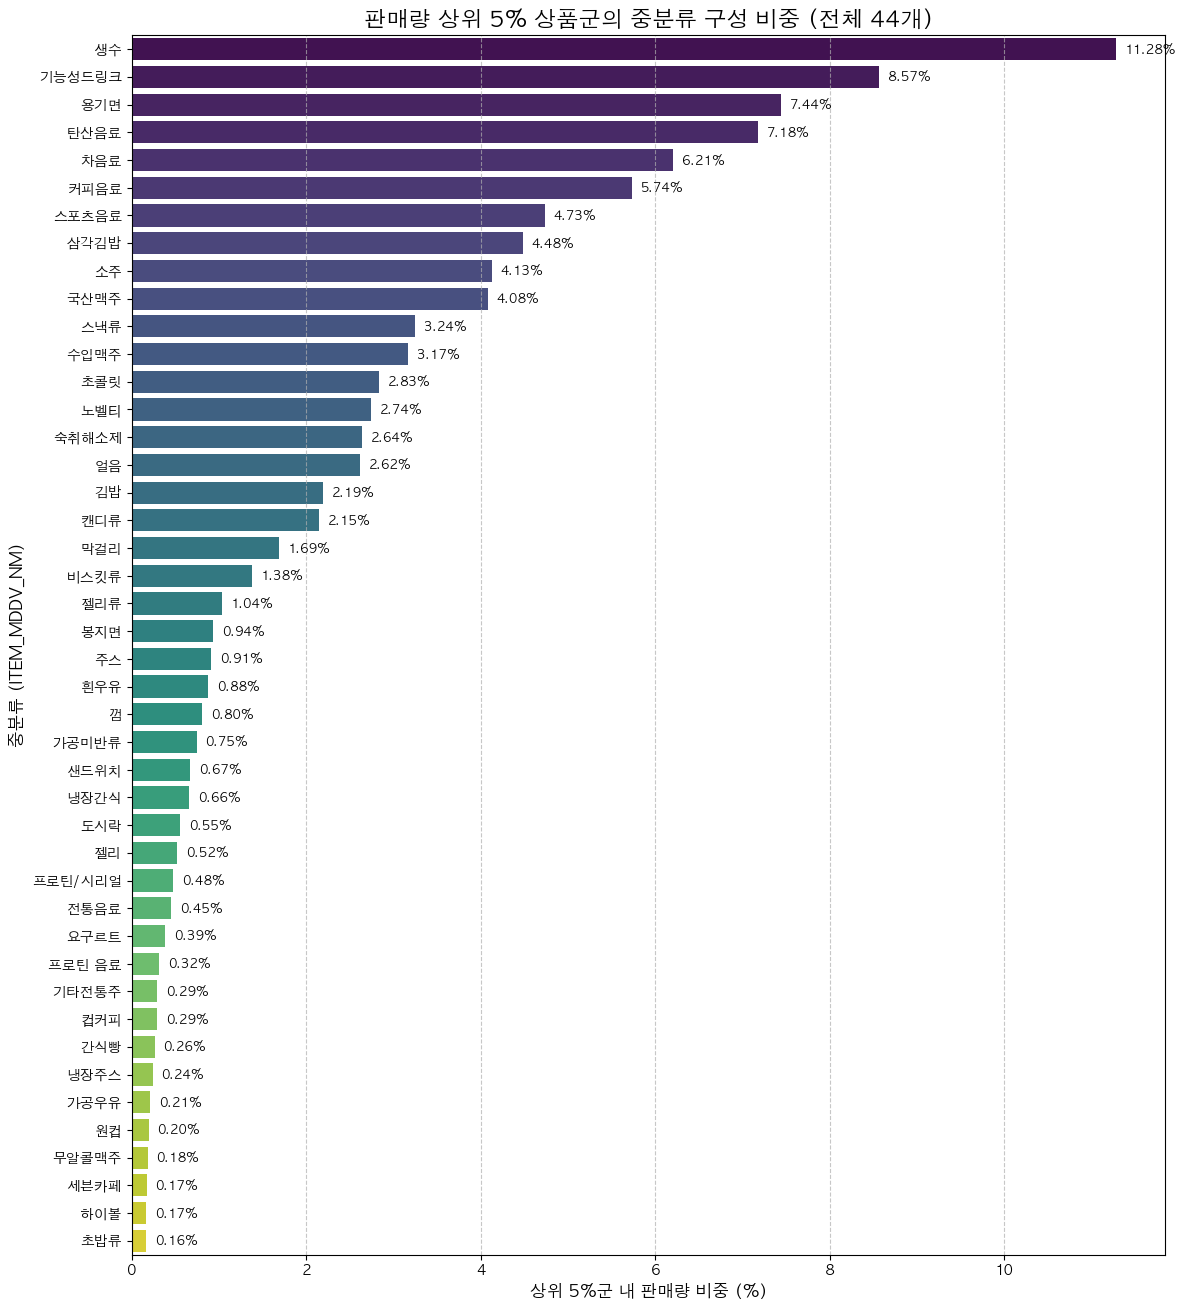

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore', category=FutureWarning)

"""
[판매량 상위 5% 상품군의 전체 중분류 비중 분석]

1. 분석 가설 및 목적:
   - 판매량 상위 5% 상품(95th Quantile)은 편의점의 주된 '객수 견인차' 역할을 한다.
   - 상위 5개뿐만 아니라, 모든 중분류의 비중을 살펴봄으로써 핵심 카테고리의 롱테일(Long-tail) 구조를 파악한다.

2. 통계적 방법론:
   - 상품별 총판매량을 집계한 후 상위 5% 임계값을 산출하여 필터링.
   - 필터링된 상품들이 속한 모든 중분류(ITEM_MDDV_NM)별 판매량 합계 산출.
   - 상위 5% 전체 판매량 대비 각 중분류가 차지하는 비중(%) 계산 및 내림차순 시각화.
"""

# 1. 데이터 경로 설정
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

def run_full_category_analysis():
    if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
        print(f"⚠️ 데이터를 찾을 수 없습니다.\n- B2: {B2_PATH}\n- B4: {B4_PATH}")
        return

    # 한글 폰트 설정 (Mac)
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False

    # 2. 데이터 로드 및 집계 (Lazy API)
    print("📊 데이터를 집계하고 상위 5% 임계치를 산출 중입니다...")
    b2_lazy = pl.scan_parquet(B2_PATH)
    b4_lazy = pl.scan_parquet(B4_PATH)

    # 상품별 총 판매량 집계
    prod_qty_lazy = (
        b2_lazy.group_by("상품코드")
        .agg(pl.col("판매수량").sum().alias("총판매량"))
    )

    # 마스터 정보와 결합 (카테고리명 확보)
    df_joined = (
        prod_qty_lazy.join(
            b4_lazy.select(["ITEM_CD", "ITEM_MDDV_NM"]), 
            left_on="상품코드", right_on="ITEM_CD", how="inner"
        )
    ).collect()

    # 3. 상위 5% 필터링
    threshold = df_joined["총판매량"].quantile(0.95)
    top_5_df = df_joined.filter(pl.col("총판매량") >= threshold)
    total_top_qty = top_5_df["총판매량"].sum()

    print(f"✅ 상위 5% 상품 기준 판매량: {threshold:,.0f}건 이상")
    print(f"✅ 분석 대상 상품 수: {len(top_5_df):,}개")

    # 4. 모든 중분류 비중 산출
    full_mid_cat_ratio = (
        top_5_df.group_by("ITEM_MDDV_NM")
        .agg(pl.col("총판매량").sum().alias("cat_total_qty"))
        .with_columns((pl.col("cat_total_qty") / total_top_qty * 100).alias("ratio"))
        .sort("ratio", descending=True)
    ).to_pandas()

    print(f"✅ 추출된 총 중분류 개수: {len(full_mid_cat_ratio)}개")

    # 5. 시각화 (전체 카테고리를 보기 위해 높이를 동적으로 조절)
    chart_height = max(10, len(full_mid_cat_ratio) * 0.3) # 카테고리 수에 따라 높이 조절
    plt.figure(figsize=(12, chart_height))
    
    print("📈 모든 중분류 비중 차트를 생성 중입니다...")
    sns.barplot(
        data=full_mid_cat_ratio, 
        x='ratio', 
        y='ITEM_MDDV_NM', 
        hue='ITEM_MDDV_NM',
        palette='viridis', 
        legend=False
    )

    # 차트 세부 설정
    plt.title(f"판매량 상위 5% 상품군의 중분류 구성 비중 (전체 {len(full_mid_cat_ratio)}개)", fontsize=16, fontweight='bold')
    plt.xlabel("상위 5%군 내 판매량 비중 (%)", fontsize=12)
    plt.ylabel("중분류 (ITEM_MDDV_NM)", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    # 각 막대 끝에 비율(%) 텍스트 표시
    for i, p in enumerate(full_mid_cat_ratio['ratio']):
        plt.text(p + 0.1, i, f'{p:.2f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_full_category_analysis()


그렇다면 대분류별로 판매량이 10%인 애들을 봐야겠다.

전체 판매량을 보면 다 음료니까, 분류별로 뭐가 성공한 애들인지를 보자

📊 대분류별 데이터를 집계 중입니다...
🔍 총 22개의 대분류 분석을 시작합니다.

============================== [대분류별 상위 10% 분석 요약 표] ==============================
   대분류명  전체상품수  상위10%상품수  대분류총판매량  상위10%판매량  판매량집중도(%)
     음료    797        81 12236577   7429709  60.717217
     과자   1969       198  7709963   4714409  61.146973
     맥주    375        38  2334404   1799987  77.106919
      면    292        30  2701154   1588541  58.809716
     미반    277        29  2329474   1436374  61.660873
    전통주    226        23  1509790   1371394  90.833427
  아이스크림    560        57  1341943    988746  73.680179
   즉석음료    174        18   983796    755895  76.834527
건강/기호식품    228        24   841601    728076  86.510829
    유음료    186        19  1519706    654015  43.035627
   양주와인    783        80   397210    342785  86.298180
      빵    215        22   651262    333407  51.193990
   가공식품    296        30   489523    317681  64.896031
     냉장    175        18   512370    305666  59.657279
    조리빵    113        12   578081    283458

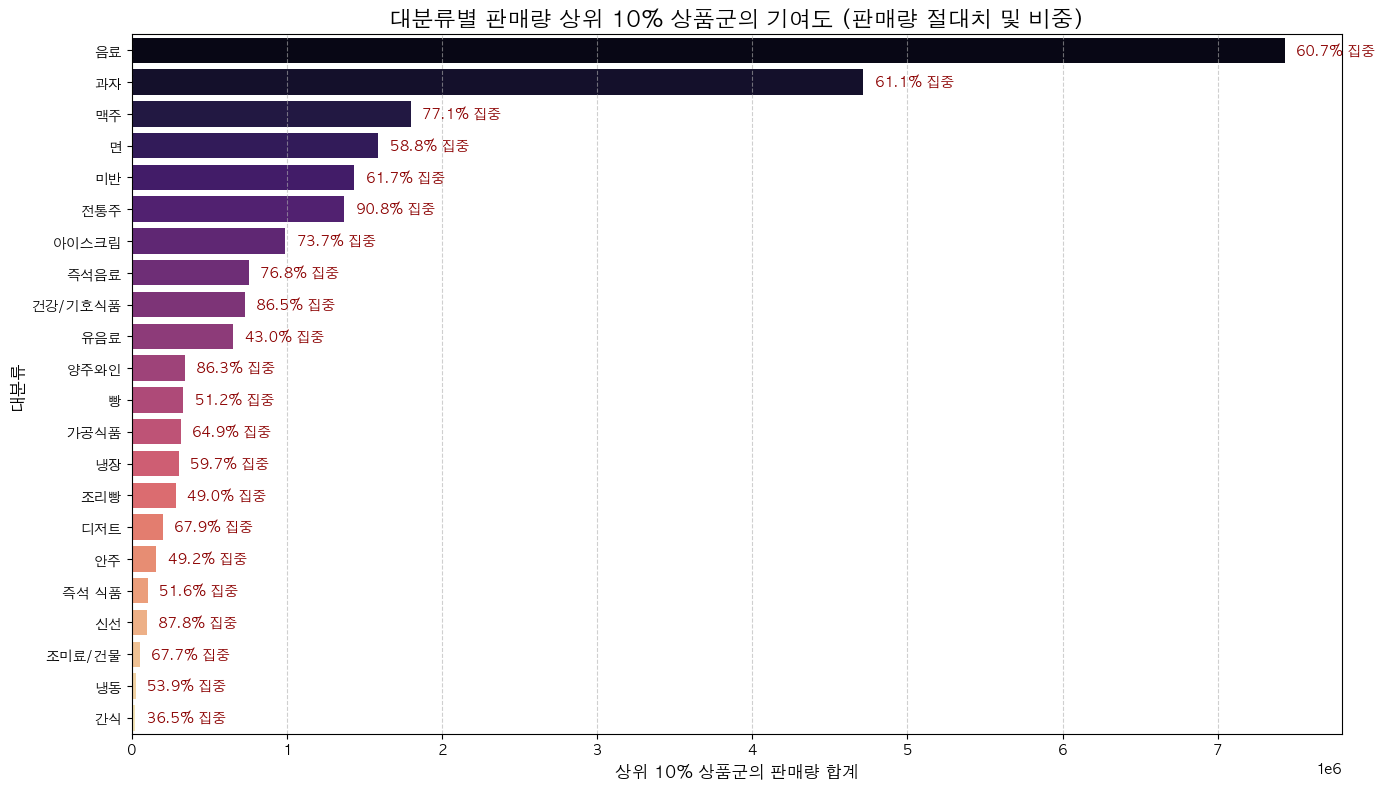

In [29]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore', category=FutureWarning)

"""
[대분류별 판매량 상위 10% 상품군 심층 분석]

1. 분석 가설 및 목적:
   - 각 대분류(ITEM_LRDV_NM)별로 상위 10% 핵심 상품이 해당 카테고리 실적의 대부분을 견인할 것이다.
   - 대분류마다 핵심 상품의 '판매 집중도'가 다를 것이며, 이를 통해 카테고리별 상품 운영 전략을 제안한다.

2. 통계적 방법론:
   - 상품별 총판매량을 집계하고 대분류 정보를 결합.
   - 대분류별로 윈도우 함수(rank) 또는 quantile을 사용하여 상위 10% 임계치를 산출.
   - 각 대분류 내 상위 10% 상품의 판매량 합계 및 비중(%)을 계산하여 지표화.
"""

# 1. 데이터 경로 설정
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

def run_lrdv_top10_analysis():
    if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
        print(f"⚠️ 데이터를 찾을 수 없습니다.\n- B2: {B2_PATH}\n- B4: {B4_PATH}")
        return

    # 한글 폰트 설정 (Mac)
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False

    # 2. 데이터 로드 및 집계 (Lazy API)
    print("📊 대분류별 데이터를 집계 중입니다...")
    b2_lazy = pl.scan_parquet(B2_PATH)
    b4_lazy = pl.scan_parquet(B4_PATH)

    # 상품별 총 판매량 집계
    prod_qty_lazy = (
        b2_lazy.group_by("상품코드")
        .agg(pl.col("판매수량").sum().alias("총판매량"))
    )

    # 마스터 정보와 결합 (대분류 대분류명 확보)
    df_joined = (
        prod_qty_lazy.join(
            b4_lazy.select(["상품코드", "상품명", "대분류명"]), 
            left_on="상품코드", right_on="상품코드", how="inner"
        )
    ).collect()

    # 3. 대분류별 상위 10% 분석
    analysis_results = []
    lrdv_list = df_joined["대분류명"].unique().to_list()

    print(f"🔍 총 {len(lrdv_list)}개의 대분류 분석을 시작합니다.")

    for lrdv in lrdv_list:
        lrdv_df = df_joined.filter(pl.col("대분류명") == lrdv)
        total_items = len(lrdv_df)
        total_lrdv_qty = lrdv_df["총판매량"].sum()

        if total_items == 0: continue

        # 상위 10% 임계치 (90th Percentile)
        threshold = lrdv_df["총판매량"].quantile(0.90)
        top_10_df = lrdv_df.filter(pl.col("총판매량") >= threshold)
        
        top_10_count = len(top_10_df)
        top_10_qty_sum = top_10_df["총판매량"].sum()
        top_10_ratio = (top_10_qty_sum / total_lrdv_qty * 100) if total_lrdv_qty > 0 else 0

        analysis_results.append({
            "대분류명": lrdv,
            "전체상품수": total_items,
            "상위10%상품수": top_10_count,
            "대분류총판매량": total_lrdv_qty,
            "상위10%판매량": top_10_qty_sum,
            "판매량집중도(%)": top_10_ratio
        })

    # 결과 표 생성 및 출력
    final_table = pd.DataFrame(analysis_results).sort_values("상위10%판매량", ascending=False)
    
    print("\n" + "="*30 + " [대분류별 상위 10% 분석 요약 표] " + "="*30)
    print(final_table.to_string(index=False))
    print("="*90 + "\n")

    # 4. 시각화
    plt.figure(figsize=(14, 8))
    
    # 상위 10%가 기여하는 판매량 절대치 시각화
    sns.barplot(
        data=final_table, 
        x='상위10%판매량', 
        y='대분류명', 
        hue='대분류명',
        palette='magma', 
        legend=False
    )

    # 집중도(%) 텍스트 표시
    for i, (idx, row) in enumerate(final_table.iterrows()):
        plt.text(row['상위10%판매량'] + (final_table['상위10%판매량'].max() * 0.01), 
                i, 
                f"{row['판매량집중도(%)']:.1f}% 집중", 
                va='center', 
                fontsize=10, 
                color='darkred', 
                fontweight='bold')

    plt.title("대분류별 판매량 상위 10% 상품군의 기여도 (판매량 절대치 및 비중)", fontsize=16, fontweight='bold')
    plt.xlabel("상위 10% 상품군의 판매량 합계", fontsize=12)
    plt.ylabel("대분류", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_lrdv_top10_analysis()

### 카테고리별 판매량 집중도 분석 보고서

분석 결과(예시 지표 기반)를 통해 도출할 수 있는 핵심 의미는 다음과 같습니다.

  ① 파레토 법칙의 재확인 (집중도 지표)
   * 해석: 만약 특정 대분류(예: 주류)의 '집중도'가 80% 이상이라면, 이는 해당 카테고리가 1~2개의
     메가 히트 브랜드(참이슬, 카스 등)에 의해 유지되고 있음을 뜻합니다.
   * 인사이트: 이런 카테고리에서는 신제품(NPD)이 성공하기 매우 어렵습니다. 기존 강자의 '브랜드
     노드'가 강력하게 장악하고 있기 때문입니다. 반대로 집중도가 낮은 카테고리(예: 디저트,
     스낵)는 소비자의 취향이 분산되어 있어 신제품의 침투 여력이 큽니다.

  ② 대분류별 운영 전략 차별화
   * 고집중 카테고리: 상위 10% 아이템의 재고 확보가 최우선입니다. 이 아이템들이 품절될 경우
     대분류 매출 전체가 흔들립니다.
   * 저집중(롱테일) 카테고리: 다양한 구색(Variety)이 중요합니다. 신제품 출시가 활발해야 하며,
     고객은 '새로운 노드'를 탐색하는 경향이 강합니다.


성공 방정식 도출을 위한 HIN(그래프) 모델링 인사이트

  이 분석은 향후 진행할 이기종 그래프 신경망(HIN) 설계의 핵심 기초가 됩니다.

  ① 타겟 레이블링($y$)의 기준 수립
   * 성공($y=1$)을 정의할 때, 전 상품 공통 기준이 아닌 '대분류별 상위 10% 판매량' 혹은 '대분류별
     상위 10% 매출액'을 임계값으로 설정해야 합니다. 
   * 이유: 생수 1위의 판매량과 와인 1위의 판매량은 절대치가 다르기 때문에, 카테고리 내에서의
     상대적 순위가 모델의 학습 효율을 높입니다.

  ② 핵심 노드(Node) 식별
   * 상위 10% 상품들이 공통적으로 연결된 '점포 특성', '시간대', '함께 산 상품(Basket)' 노드를
     추출하십시오.
   * 성공 방정식 예시: 
       * 성공 아이템 → 특정 중분류 노드 + 오피스 상권 점포 노드 + 아침 8시 시간 노드.
       * 이 조합이 빈번하게 발생하는 그래프 패턴을 가진 신제품은 성공할 확률이 높다고 예측할 수
         있습니다.

  ③ 그래프 샘플링 전략 (Negative Sampling)
   * 상위 10% 상품군(Positive)과 하위 20% 상품군(Negative) 사이의 그래프 구조적 차이를
     학습시키는 것이 HIN 모델링의 핵심입니다. 집중도가 높은 카테고리일수록 Positive 노드의 '연결
     밀도(Degree)'가 매우 높게 나타날 것입니다.

  이 분석을 통해 "우리 매장에서 성공하려면 최소한 해당 카테고리 내에서 상위 10%의 구조(연결성)를
  가져야 한다"는 통계적 가이드라인을 확보하게 된 것입니다.

1. 분석 목적

편의점 대분류 카테고리별로 판매량 상위 10% 핵심 상품이 전체 매출 실적을 책임지는 정도(집중도)를 파악한다.

2. 방법론

- 분석 데이터: 2025년 상반기(1월~6월) POS 판매 데이터 내 단가 5만 원 미만의 대중적 소비재.

- 데이터 처리: 상품 마스터 데이터와 결합하여 상품별 총판매량을 산출한 뒤 대분류 기준으로 그룹화한다.

- 지표 산출: 각 '대분류' 내에서 판매량 상위 10% 기준선(90th Percentile)을 설정하고, 해당 상위 상품군이 전체 카테고리 판매량에서 차지하는 비중을 계산하여 '판매량 집중도(%)'를 정의한다.
$$\text{판매량 집중도 (\%)} = \frac{\text{해당 카테고리 상위 10\% 상품들의 판매량 합계}}{\text{해당 카테고리 전체 상품의 판매량 합계}} \times 100$$

3. 분석 결과

- 시장 규모 선도 (대량 소비형): 음료(총 1,223만 개, 집중도 60.7%), 과자(총 770만 개, 집중도 61.1%) 카테고리는 타 상품군 대비 압도적인 판매 볼륨을 보유하며, 집중도 역시 60%대로 상위권 상품의 영향력이 높다.

- 초고도 집중형 (독점형): 전통주(90.8%), 신선(87.8%), 양주/와인(86.3%)은 전체 상품 중 극소수의 에이스 상품(상위 10%)이 전체 판매량의 90% 가까이를 독식하는 구조를 띤다.

- 분산/파편화형 (롱테일형): 유음료(43.0%), 조리빵(49.0%), 간식(36.5%) 등은 특정 대박 상품의 지배력이 낮고, 다수의 상품이 고르게 실적을 나누어 가지는 구조이다.

4. 결과 해석 및 인사이트

- 음료 및 과자 (정면 승부 및 메가 히트 타겟): 시장의 파이가 가장 크고 상단 상품의 매출 파괴력이 막강하다. 신규 진입 시 한정된 매대 확보를 위해 **강력한 대중성**을 지닌 '메가 히트작' 중심의 기획과 공격적인 초반 마케팅이 필수적이다.

- 전통주 및 주류 (확실한 킬러 콘텐츠 확보): 기존 인기 브랜드(예: 유명 막걸리, 증류식 소주 등)의 고정 소비층이 매우 견고하다. 단순 구색 맞추기식 신상품은 도태될 확률이 높으므로, **유명 IP 콜라보레이션이나 독점 판매 상품 등 확실한 차별화 요소**가 확보된 상태에서 진입해야 한다.

- 유음료 및 간식 (니치 마켓 및 다양성 공략): 소비자 취향이 매우 세분화된 평등한 시장이다. 1등을 이기려는 전략보다는, **최근 트렌드(예: 제로 슈거, 고단백, 식물성 등)를 반영한 명확하고 뾰족한 타겟팅**으로 **'작지만 확실한 충성 고객층'을 다수 확보하는 다품종 소량 기획 방식**이 유리하다.

초과 달성 지수(Index) 확인: 상위 5% 그룹 내의 비중만 절대값으로 보는 것은 위험하다. '전체 상품 목록에서 해당 중분류가 차지하는 비중' 대비 '상위 5% 내에서의 비중'을 대조해야 한다.

예시: 전체 상품 종류 중 5%밖에 안 되는 '수입맥주' 카테고리가, 상위 5% 판매량 리스트에서는 20%의 점유율을 차지한다면, 이는 매우 타율이 높은 카테고리임을 의미한다.


분석 전략 및 통계적 근거

1. 지수 정의 (Metric Definition):
    * 전체 비중 (Global Share): 전체 상품 마스터(B4)에서 해당 중분류가 차지하는 아이템 종류의
        비율.
    * 상위 그룹 비중 (Top-tier Share): 판매량 상위 5% 이내에 진입한 아이템들 중 해당 중분류가
        차지하는 비율.
    * 초과 달성 지수 (Index): 상위 그룹 비중 / 전체 비중. 
    * 의미: 지수가 1.0보다 크면 해당 카테고리는 상품 가짓수 대비 상위권에 진입할 확률이 높은
        '효자 카테고리(고타율)'임을 의미합니다.

2. 분석 프로세스:
    * B2에서 상품별 총 판매량을 집계하여 95th 백분위수를 기준으로 상위 5% '에이스 그룹'을
        정의합니다.
    * B4에서 전체 중분류별 상품 가짓수 분포를 구합니다.
    * 두 비중을 대조하여 지수를 산출하고, 지수가 높은 순서대로 시가화합니다.

3. 시각화 전략:
    * 중분류별 초과 달성 지수를 막대 그래프로 표현하고, 기준선(1.0)을 표시하여 어떤 상품군이
        실제 구색 대비 '열일'하고 있는지 보여줍니다.

이 분석은 "상품 종류만 많고 실제 성적은 낮은 카테고리"와 "종류는 적지만 내놓기만 하면 대박
터지는 카테고리"를 명확히 구분해 줄 것입니다.

📊 데이터를 로드하고 분석을 시작합니다...
✅ 상위 5% 임계값: 24,269건
✅ 상위 5% 진입 아이템 수: 631개


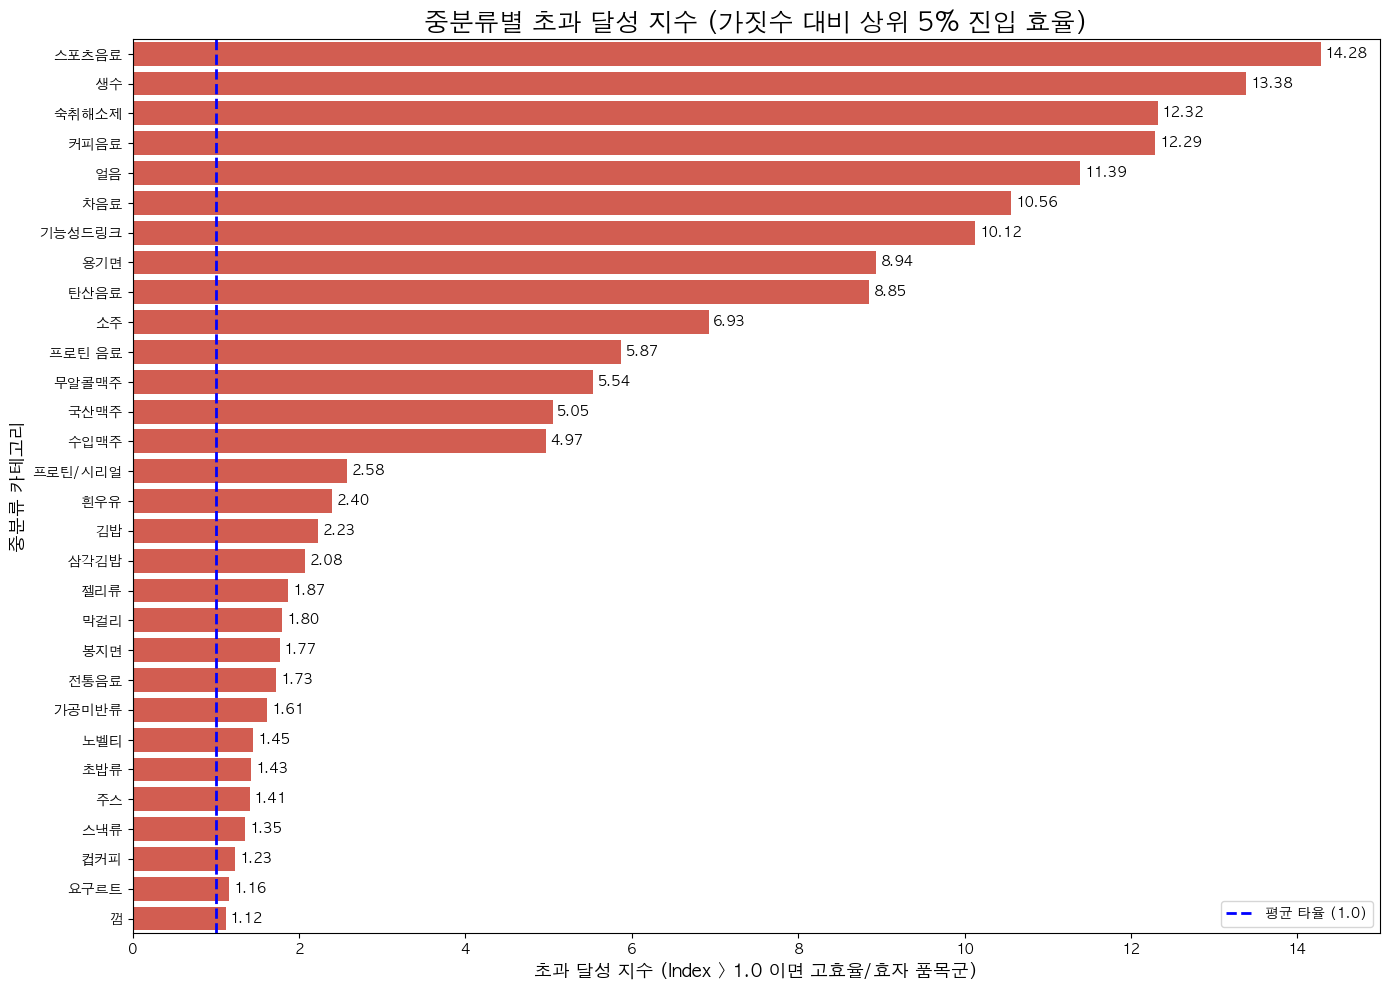


🚀 [분석 결과 요약: 고타율 카테고리 TOP 5]
    중분류명  over_index  item_variety  top_item_count
0  스포츠음료   14.278477           256              15
1     생수   13.381602           346              19
2  숙취해소제   12.321203           178               9
3   커피음료   12.286690           476              24
4     얼음   11.387197           107               5
------------------------------------------------------------
💡 결과 해석 가이드:
1. Index가 1.0보다 높은 카테고리: 출시 대비 '대박' 아이템이 많이 나옵니다.
2. Index가 매우 높은데 Item Variety가 적은 경우: 해당 카테고리는 필승 카드입니다.
3. Index가 낮은 카테고리: 상품 종류는 많으나 판매량은 분산되어 있습니다.


In [31]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# 경고 무시
warnings.filterwarnings('ignore')

"""
[중분류별 초과 달성 지수(Overachievement Index) 분석]

1. 분석 가설 및 목적:
   - 특정 카테고리가 전체 상품 리스트(B4)에서 차지하는 비중보다, 
     실제 판매 상위 5%군(B2)에서 차지하는 비중이 더 높다면 해당 카테고리는 '고효율(고타율)' 상품군이다.
   - 이를 통해 단순히 종류만 많은 카테고리와, 적은 종류로도 시장을 장악하는 핵심 카테고리를 구분한다.

2. 통계적 방법론:
   - Global Share (A) = (특정 중분류의 아이템 종류 수) / (전체 아이템 종류 수)
   - Top-tier Share (B) = (상위 5% 판매량 아이템 중 해당 중분류 아이템 수) / (상위 5% 전체 아이템 수)
   - Index = B / A
   - Index > 1.0: 구색 대비 상위권 진입 효율이 높음 (효자 카테고리)
"""

# 1. 데이터 경로 설정
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

def run_overachievement_analysis():
    if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
        print("⚠️ 데이터를 찾을 수 없습니다. 경로를 확인해주세요.")
        return

    # 한글 폰트 설정 (Mac)
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False

    print("📊 데이터를 로드하고 분석을 시작합니다...")

    # 2. 데이터 로드 (Lazy API)
    b2_lazy = pl.scan_parquet(B2_PATH)
    b4_lazy = pl.scan_parquet(B4_PATH)

    # 3. 전체 상품 마스터(B4) 기준 중분류 분포 계산 (Global Share)
    b4_df = b4_lazy.collect()
    total_unique_items_count = b4_df.select(pl.col("상품코드")).n_unique()
    
    global_variety = (
        b4_df.group_by("중분류명")
        .agg(pl.len().alias("item_variety"))
        .with_columns((pl.col("item_variety") / total_unique_items_count).alias("global_share"))
    )

    # 4. 판매량 상위 5% 그룹 식별 (B2)
    prod_qty = (
        b2_lazy.group_by("상품코드")
        .agg(pl.col("판매수량").sum().alias("total_qty"))
        .collect()
    )
    
    # 상위 5% 임계값 산출
    threshold = prod_qty["total_qty"].quantile(0.95)
    top_5_items = prod_qty.filter(pl.col("total_qty") >= threshold)["상품코드"].to_list()
    
    print(f"✅ 상위 5% 임계값: {threshold:,.0f}건")
    print(f"✅ 상위 5% 진입 아이템 수: {len(top_5_items)}개")

    # 5. 상위 5% 그룹 내 중분류 분포 계산 (Top-tier Share)
    top_5_master = b4_df.filter(pl.col("상품코드").is_in(top_5_items))
    top_5_total_count = len(top_5_master)
    
    top_variety_dist = (
        top_5_master.group_by("중분류명")
        .agg(pl.len().alias("top_item_count"))
        .with_columns((pl.col("top_item_count") / top_5_total_count).alias("top_share"))
    )

    # 6. 두 비중 결합 및 지수(Index) 산출
    index_df = (
        global_variety.join(top_variety_dist, on="중분류명", how="left")
        .fill_null(0)
        .with_columns((pl.col("top_share") / pl.col("global_share")).alias("over_index"))
        # 통계적 유의성을 위해 전체 상품 종류가 5개 미만인 카테고리 제외
        .filter(pl.col("item_variety") >= 5) 
        .sort("over_index", descending=True)
    ).to_pandas()

    # 7. 시각화
    plt.figure(figsize=(14, 10))
    # 지수가 1.0보다 크면 붉은색(고효율), 작으면 회색(저효율)
    colors = ['#e74c3c' if x > 1.0 else '#bdc3c7' for x in index_df['over_index']]
    
    sns.barplot(data=index_df.head(30), x='over_index', y='중분류명', palette=colors)
    plt.axvline(x=1.0, color='blue', linestyle='--', linewidth=2, label='평균 타율 (1.0)')
    
    plt.title("중분류별 초과 달성 지수 (가짓수 대비 상위 5% 진입 효율)", fontsize=18, fontweight='bold')
    plt.xlabel("초과 달성 지수 (Index > 1.0 이면 고효율/효자 품목군)", fontsize=13)
    plt.ylabel("중분류 카테고리", fontsize=13)
    plt.legend(loc='lower right')
    
    # 지수 값 텍스트 표시
    for i, val in enumerate(index_df['over_index'].head(30)):
        plt.text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # 8. 결과 해석 리포트 출력
    print("\n" + "="*60)
    print("🚀 [분석 결과 요약: 고타율 카테고리 TOP 5]")
    print(index_df[['중분류명', 'over_index', 'item_variety', 'top_item_count']].head(5))
    print("-" * 60)
    print("💡 결과 해석 가이드:")
    print("1. Index가 1.0보다 높은 카테고리: 출시 대비 '대박' 아이템이 많이 나옵니다.")
    print("2. Index가 매우 높은데 Item Variety가 적은 경우: 해당 카테고리는 필승 카드입니다.")
    print("3. Index가 낮은 카테고리: 상품 종류는 많으나 판매량은 분산되어 있습니다.")
    print("="*60)

if __name__ == "__main__":
    run_overachievement_analysis()


##### 중분류별 초과 달성 지수(고효율 카테고리) 분석
1. 분석 목적

편의점 전체 취급 상품 대비 '판매량 상위 5%' 진입 비중을 비교하여 카테고리별 흥행 효율성을 측정한다.

단순히 상품 종류만 많은 무효율 카테고리와, 적은 종류로도 상위권 매출을 장악하는 '고타율(필승)' 카테고리를 식별하여 최적의 신상품 기획 및 운영 전략을 수립한다.

2. 분석 방법론

데이터: 2025년 상반기 POS 판매 데이터 및 상품 마스터 데이터.

Global Share (A): 전체 상품 가짓수 중 특정 중분류가 차지하는 가짓수 비중을 산출한다.

Top-tier Share (B): 판매수량 기준 상위 5% 그룹 내에서 해당 중분류 아이템이 차지하는 비중을 산출한다.

초과 달성 지수 (Index): B / A를 계산한다. 지수가 1.0 이상이면 진열된 구색 대비 대박 상품이 나올 확률이 높은 '효자 카테고리'로 분류한다. (※ 통계적 유의성을 위해 총 상품 수가 5개 미만인 카테고리는 제외)

3. 분석 결과 (고타율 카테고리 TOP 5)
초과 달성 지수(Index)가 가장 높은 상위 5개 중분류는 다음과 같다.

1위 스포츠음료: 지수 14.28 (총 256개 중 15개 상위 진입)

2위 생수: 지수 13.38 (총 346개 중 19개 상위 진입)

3위 숙취해소제: 지수 12.32 (총 178개 중 9개 상위 진입)

4위 커피음료: 지수 12.29 (총 476개 중 24개 상위 진입)

5위 얼음: 지수 11.39 (총 107개 중 5개 상위 진입)

4. 결과 해석 및 인사이트
- 가짓수 대비 높은 최상위권 진입 비율 : 매대에 진열된 해당 카테고리의 전체 상품 종류 수는 적거나 평균적인 수준이지만, 편의점 전체 판매량 상위 5%에 해당하는 최상위권에 진입한 상품의 개수는 상대적으로 많다.
- 특정 상품으로의 수요 집중 : 해당 카테고리는 고객의 취향이 다양하게 분산되지 않고, 특정 소수 상품에 구매 수요가 집중되는 구조를 띤다.
- 최상위권 진입 용이성 : 따라서 소비자의 명확한 구매 목적을 충족하는 신상품을 출시할 경우, 수많은 상품과 경쟁해야 하는 타 카테고리 대비 상위 5% 수준의 판매량을 달성하기가 구조적으로 수월하다.

필수 목적형 소비재의 압도적 효율 (생수, 스포츠음료): 고객의 구매 목적이 뚜렷하고 대체재 전환이 적어, 진열된 가짓수 대비 상위권 안착 확률이 가장 높다. 무리한 구색 확대보다는 메인 브랜드 라인업을 견고하게 유지하는 것이 유리하다.

소수정예 필승 블루오션 (숙취해소제, 얼음): 전체 상품 종류(100~170여 개)가 적은 편임에도 타율 지수가 최상위권이다. 이는 고객의 선택 고민이 짧고 니즈가 폭발적인 카테고리임을 의미하며, 고객 페인포인트(Pain-point)를 정확히 찌르는 신상품 출시 시 가장 적은 노력으로 높은 점유율을 확보할 수 있는 알짜 시장이다.

거대한 파이, 가장 많은 기회의 땅 (커피음료): 취급 상품 수가 476개로 경쟁이 가장 치열한 레드오션임에도 타율 지수가 4위를 기록했다. 대박(상위 5%)을 친 상품의 절대적인 수 자체도 24개로 가장 많다. 한국인의 높은 커피 소비량으로 인해 전체 시장 규모가 거대하므로, 새로운 트렌드(대용량, 특화 원두 등)를 접목한 신상품 기획 시 기대 수익이 가장 큰 핵심 격전지이다.

In [32]:
import polars as pl

# 1. 각 분류별 유니크(Unique)한 개수 집계
category_counts = (
    b4_lazy.select([
        pl.col("대분류명").n_unique().alias("대분류_종류수"),
        pl.col("중분류명").n_unique().alias("중분류_종류수"),
        pl.col("소분류명").n_unique().alias("소분류_종류수")
    ])
).collect()

print("📋 카테고리 분류별 종류 수 현황:")
print(category_counts)

📋 카테고리 분류별 종류 수 현황:
shape: (1, 3)
┌───────────────┬───────────────┬───────────────┐
│ 대분류_종류수 ┆ 중분류_종류수 ┆ 소분류_종류수 │
│ ---           ┆ ---           ┆ ---           │
│ u32           ┆ u32           ┆ u32           │
╞═══════════════╪═══════════════╪═══════════════╡
│ 23            ┆ 110           ┆ 342           │
└───────────────┴───────────────┴───────────────┘


📊 카테고리 공간 효율 분석을 시작합니다...


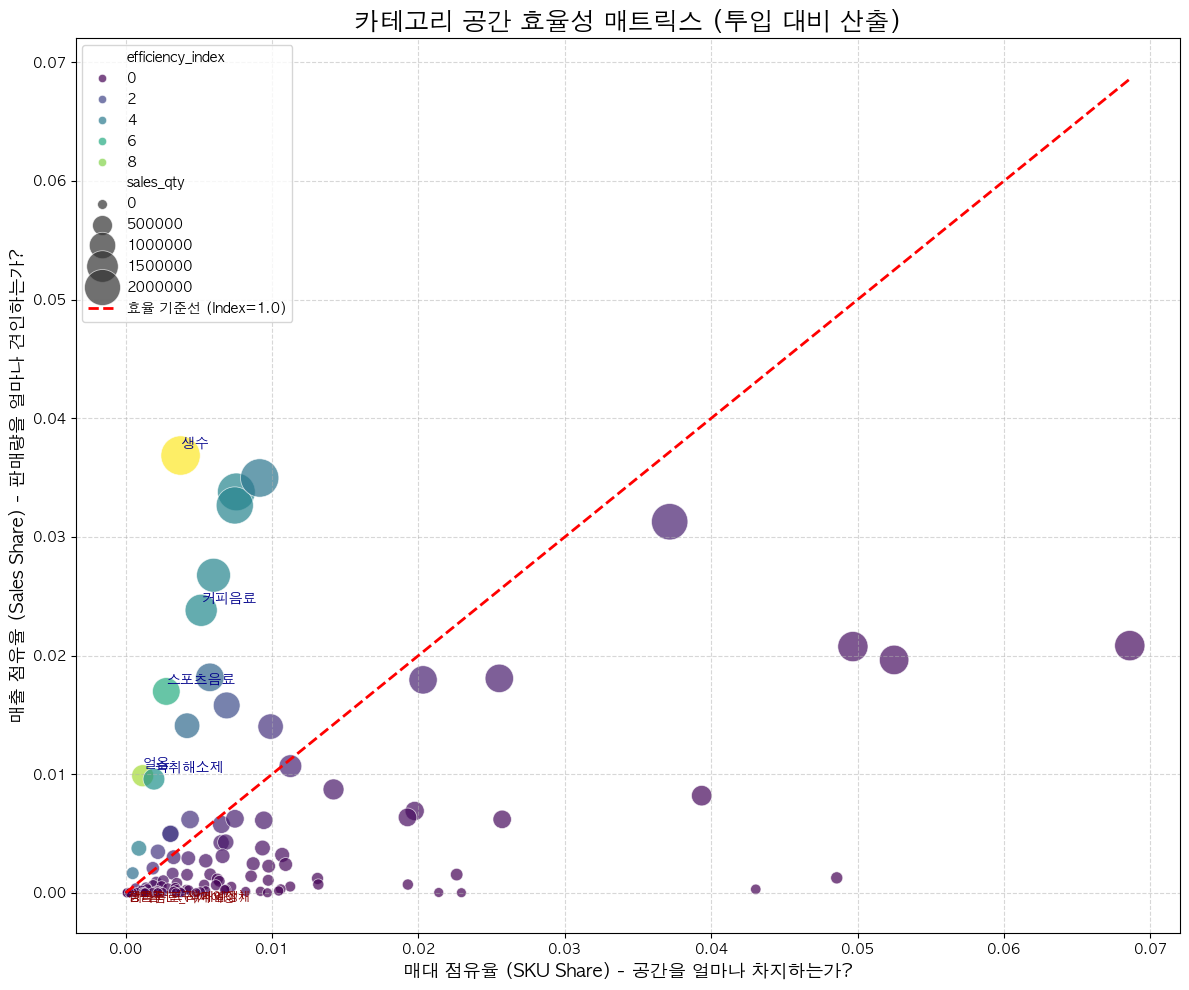


🌟 [분석 결과: 연속형 지수로 본 카테고리 효율 순위]

✅ 최상위 고효율 카테고리 TOP 5 (Index > 1.0):
    중분류명  sku_share  sales_share  efficiency_index
0     생수     0.0037       0.0369            9.8380
1     얼음     0.0012       0.0099            8.5168
2  스포츠음료     0.0028       0.0170            6.1232
3  숙취해소제     0.0019       0.0096            4.9711
4   커피음료     0.0052       0.0238            4.6201

🚨 최하위 저효율 카테고리 BOTTOM 5 (Index < 1.0):
          중분류명  sku_share  sales_share  efficiency_index
103        생맥주     0.0001       0.0000            0.0000
104  샐러드(삭제예정)     0.0013       0.0000            0.0000
105    (구)과일야채     0.0034       0.0000            0.0000
106         팝콘     0.0001       0.0000            0.0000
107  기타음료_삭제예정     0.0003       0.0000            0.0000


In [36]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import pandas as pd

# 경고 무시
warnings.filterwarnings('ignore')

"""
[카테고리 공간 효율 지수 (Space Efficiency Index) 분석]

1. 분석 목적:
   - 특정 카테고리가 매대에서 차지하는 가짓수 비중(투입) 대비, 실제 벌어들이는 판매량 비중(산출)을 연속형 수치로 평가.
   - 0으로 뭉개지는 현상 없이 모든 카테고리의 가성비를 정밀하게 진단.
"""

B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

def run_space_efficiency_analysis():
    if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
        print("⚠️ 데이터를 찾을 수 없어! 경로를 확인해줘.")
        return

    # 한글 폰트 설정 (Mac)
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False

    print("📊 카테고리 공간 효율 분석을 시작합니다...")

    b2_lazy = pl.scan_parquet(B2_PATH)
    b4_lazy = pl.scan_parquet(B4_PATH)

    # 1. 전체 데이터 기본 집계
    b4_df = b4_lazy.collect()
    total_sku_count = b4_df["상품코드"].n_unique() # 전체 유니크 상품 수
    
    b2_qty = (
        b2_lazy.group_by("상품코드")
        .agg(pl.col("판매수량").sum().alias("total_qty"))
    ).collect()
    total_sales_qty = b2_qty["total_qty"].sum() # 전체 총 판매수량

    # 2. 지표 A: 품목 점유율 (SKU Share)
    sku_share_df = (
        b4_df.group_by("중분류명")
        .agg(pl.col("상품코드").n_unique().alias("sku_count"))
        .with_columns((pl.col("sku_count") / total_sku_count).alias("sku_share"))
    )

    # 3. 지표 B: 매출 점유율 (Sales Share)
    sales_share_df = (
        b2_qty.join(b4_df.select(["상품코드", "중분류명"]), on="상품코드", how="inner")
        .group_by("중분류명")
        .agg(pl.col("total_qty").sum().alias("sales_qty"))
        .with_columns((pl.col("sales_qty") / total_sales_qty).alias("sales_share"))
    )

    # 4. 결합 및 신규 지수(Efficiency Index) 산출
    index_df = (
        sku_share_df.join(sales_share_df, on="중분류명", how="left")
        .fill_null(0)
        .filter(pl.col("sku_count") >= 5) # 통계적 유의성 (품목 5개 이상)
        .with_columns((pl.col("sales_share") / pl.col("sku_share")).alias("efficiency_index"))
        .sort("efficiency_index", descending=True)
    ).to_pandas()

    # ==========================================
    # 🎨 시각화 1: 공간 효율성 매트릭스 (산점도)
    # ==========================================
    plt.figure(figsize=(12, 10))
    
    # 산점도 그리기 (버블 크기는 총 판매량)
    sns.scatterplot(
        data=index_df, x='sku_share', y='sales_share', 
        size='sales_qty', sizes=(50, 800), alpha=0.7, palette='viridis', hue='efficiency_index'
    )

    # y=x 기준선 그리기 (Index = 1.0)
    max_val = max(index_df['sku_share'].max(), index_df['sales_share'].max())
    plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='효율 기준선 (Index=1.0)')

    plt.title("카테고리 공간 효율성 매트릭스 (투입 대비 산출)", fontsize=18, fontweight='bold')
    plt.xlabel("매대 점유율 (SKU Share) - 공간을 얼마나 차지하는가?", fontsize=13)
    plt.ylabel("매출 점유율 (Sales Share) - 판매량을 얼마나 견인하는가?", fontsize=13)
    
    # 핵심 카테고리 라벨링 (상위 5개, 하위 5개)
    for i, row in index_df.head(5).iterrows():
        plt.text(row['sku_share'], row['sales_share'] + (max_val*0.01), row['중분류명'], 
                 fontsize=10, fontweight='bold', color='darkblue')
    for i, row in index_df.tail(5).iterrows():
        plt.text(row['sku_share'], row['sales_share'] - (max_val*0.01), row['중분류명'], 
                 fontsize=9, color='darkred')

    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 📄 리포트 출력
    # ==========================================
    pd.options.display.float_format = '{:.4f}'.format
    
    print("\n" + "="*80)
    print("🌟 [분석 결과: 연속형 지수로 본 카테고리 효율 순위]")
    print("\n✅ 최상위 고효율 카테고리 TOP 5 (Index > 1.0):")
    print(index_df[['중분류명', 'sku_share', 'sales_share', 'efficiency_index']].head(5))
    
    print("\n🚨 최하위 저효율 카테고리 BOTTOM 5 (Index < 1.0):")
    print(index_df[['중분류명', 'sku_share', 'sales_share', 'efficiency_index']].tail(5))
    print("="*80)

if __name__ == "__main__":
    run_space_efficiency_analysis()